In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import streamlit as st

In [8]:
df2019 = pd.read_csv("data/full_2019.csv")

df2019_sample_big = df2019.sample(frac = 0.3)

df2019_sample_small = df2019.sample(frac = 0.05)

In [9]:
df2019_sample_small[df2019_sample_small['surface_reelle_bati'].isna()][df2019_sample_small['surface_terrain'].isna()]

/Library/Python/3.7/site-packages/ipykernel_launcher.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """Entry point for launching an IPython kernel.


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
980037,2019-392057,2019-05-28,1,Vente en l'état futur d'achèvement,166000.0,NaN,NaN,LE GINESTIERE,B011,31130.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.545274,43.588627
1008513,2019-406446,2019-07-24,1,Vente en l'état futur d'achèvement,177500.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.409317,43.600860
143249,2019-60090,2019-04-08,1,Vente,147000.0,5905.0,NaN,CD CHEMIN DEPARTEMENTAL 53,0038,6440.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,7.376054,43.790094
3302642,2019-1390346,2019-03-01,1,Vente,330000.0,50.0,NaN,AV DE SAVIGNY,3295,93600.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.513604,48.949838
2992751,2019-1255685,2019-11-14,1,Vente,73000.0,6.0,NaN,RUE FERDINAND BUISSON,0451,85000.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,-1.439936,46.663805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3255711,2019-1367027,2019-02-14,1,Vente en l'état futur d'achèvement,22000.0,3.0,NaN,RUE DE FONTENAY,3540,92320.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,2.288379,48.798336
2366288,2019-988462,2019-03-22,1,Vente,264325.0,31.0,NaN,RUE DOC ROLLET,1330,69100.0,...,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,4.884709,45.766838
3391566,2019-1434734,2019-11-04,1,Vente en l'état futur d'achèvement,259000.0,NaN,NaN,LES TERRES NEUVES,B087,95310.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.130475,49.033029
3315637,2019-1396408,2019-05-23,1,Vente en l'état futur d'achèvement,4142961.5,170.0,NaN,RUE PAUL ET CAMILLE THOMOUX,0860,93330.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.529040,48.867736


In [10]:
df_dept = pd.read_csv('data/departements-france.csv')

df_dept['code_departement'] = df_dept['code_departement'].apply(lambda code_dept : str(code_dept))

df_dept.head()

,code_departement,nom_departement,code_region,nom_region
0,01,Ain,84,Auvergne-Rhône-Alpes
1,02,Aisne,32,Hauts-de-France
2,03,Allier,84,Auvergne-Rhône-Alpes
3,04,Alpes-de-Haute-Provence,93,Provence-Alpes-Côte d'Azur
4,05,Hautes-Alpes,93,Provence-Alpes-Côte d'Azur


In [11]:
df_dept.dtypes

code_departement    object
nom_departement     object
code_region          int64
nom_region          object
dtype: object

In [12]:
df2019_sample_small['code_departement'] = df2019_sample_small['code_departement'].apply(lambda code_dept : str(code_dept))
df2019_sample_small['code_departement'] = df2019_sample_small['code_departement'].apply(lambda code_dept : '0' + code_dept if (len(code_dept) == 1) else code_dept)

In [7]:
df2019_sample_small['surface_reelle_bati'] = df2019_sample_small['surface_reelle_bati'].fillna(0.0)

In [8]:
df2019_sample_small.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 176661 entries, 3029778 to 1876334
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id_mutation                   176661 non-null  object 
 1   date_mutation                 176661 non-null  object 
 2   numero_disposition            176661 non-null  int64  
 3   nature_mutation               176661 non-null  object 
 4   valeur_fonciere               174646 non-null  float64
 5   adresse_numero                103939 non-null  float64
 6   adresse_suffixe               7730 non-null    object 
 7   adresse_nom_voie              174919 non-null  object 
 8   adresse_code_voie             174923 non-null  object 
 9   code_postal                   174918 non-null  float64
 10  code_commune                  176661 non-null  object 
 11  nom_commune                   176661 non-null  object 
 12  code_departement              176661 

In [9]:
df2019_sample_small.dtypes

id_mutation                      object
date_mutation                    object
numero_disposition                int64
nature_mutation                  object
valeur_fonciere                 float64
adresse_numero                  float64
adresse_suffixe                  object
adresse_nom_voie                 object
adresse_code_voie                object
code_postal                     float64
code_commune                     object
nom_commune                      object
code_departement                 object
ancien_code_commune             float64
ancien_nom_commune               object
id_parcelle                      object
ancien_id_parcelle               object
numero_volume                    object
lot1_numero                      object
lot1_surface_carrez             float64
lot2_numero                      object
lot2_surface_carrez             float64
lot3_numero                      object
lot3_surface_carrez             float64
lot4_numero                     float64


In [10]:
type_local = df2019_sample_small['type_local'].unique()

type_local

array(['Dépendance', 'Maison', nan, 'Appartement',
       'Local industriel. commercial ou assimilé'], dtype=object)

In [11]:
df2019_sample_small['date_mutation'] = pd.to_datetime(df2019_sample_small['date_mutation'])


df2019_sample_small['date_mutation']

3029778   2019-10-21
1845794   2019-02-06
2777692   2019-06-20
3131967   2019-05-24
453216    2019-01-19
             ...    
822857    2019-11-28
288373    2019-12-27
757311    2019-10-18
3159610   2019-07-09
1876334   2019-07-12
Name: date_mutation, Length: 176661, dtype: datetime64[ns]

In [12]:
def count_rows(rows):
    return len(rows)

In [13]:
def get_month(dt):
    return dt.month

In [14]:
df2019_sample_small['mutation_month'] = df2019_sample_small['date_mutation'].apply(get_month)

In [15]:
df2019_sample_small = pd.merge(df2019_sample_small , df_dept , on = 'code_departement' , how = 'left')

df2019_sample_small.head()


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,mutation_month,nom_departement,code_region,nom_region
0,2019-1273553,2019-10-21,1,Vente,88000.0,42.0,NaN,RUE BONNE FONTAINE,4620,85300.0,...,NaN,NaN,NaN,NaN,-1.875529,46.847310,10,Vendée,52,Pays de la Loire
1,2019-753371,2019-02-06,1,Vente,249000.0,9001.0,NaN,RUE DANTON,0160,51370.0,...,NaN,NaN,NaN,NaN,3.985962,49.260855,2,Marne,44,Grand Est
2,2019-1162845,2019-06-20,1,Vente,115765.0,2.0,NaN,PAS DU PORT,0810,78840.0,...,sols,NaN,NaN,62.0,1.694961,49.062339,6,Yvelines,11,Île-de-France
3,2019-1308953,2019-05-24,2,Vente,205000.0,NaN,NaN,SUR LA COTE D YONNE,B026,89460.0,...,terres,NaN,NaN,3250.0,3.674335,47.630249,5,Yonne,27,Bourgogne-Franche-Comté
4,2019-189484,2019-01-19,1,Vente,142000.0,5204.0,NaN,CHENE LAMOTTE- MONTCHAUVET,E375,14350.0,...,sols,NaN,NaN,500.0,-0.723151,48.935167,1,Calvados,28,Normandie


In [16]:
df2019_sample_small['valeur_fonciere'] = df2019_sample_small.groupby(by = ['nom_departement' , 'type_local' , 'nombre_pieces_principales'])['valeur_fonciere'].transform(lambda x: x.fillna((x.mean())))

In [17]:
df2019_sample_small['valeur_fonciere'].isna().sum()

82079

In [18]:
test_avant = df2019_sample_small
test_apres = df2019_sample_small

In [19]:
df2019_sample_small['prix_m_carre'] = df2019_sample_small['valeur_fonciere'] / df2019_sample_small['surface_reelle_bati']

In [20]:
df2019_sample_small[df2019_sample_small['prix_m_carre'] == np.inf]

,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,mutation_month,nom_departement,code_region,nom_region,prix_m_carre
0,2019-1273553,2019-10-21,1,Vente,88000.0,42.0,NaN,RUE BONNE FONTAINE,4620,85300.0,...,NaN,NaN,NaN,-1.875529,46.847310,10,Vendée,52,Pays de la Loire,inf
1,2019-753371,2019-02-06,1,Vente,249000.0,9001.0,NaN,RUE DANTON,0160,51370.0,...,NaN,NaN,NaN,3.985962,49.260855,2,Marne,44,Grand Est,inf
7,2019-398817,2019-11-20,1,Vente,88000.0,53.0,NaN,RUE EDMOND ROSTAND,2888,31200.0,...,NaN,NaN,NaN,1.461085,43.643999,11,Haute-Garonne,76,Occitanie,inf
9,2019-268092,2019-12-23,1,Vente,47848340.0,9003.0,NaN,CITE ST CHARLES PAV AVAUGOUR,A090,22100.0,...,NaN,NaN,7275.0,-2.047319,48.455799,12,Côtes-d'Armor,53,Bretagne,inf
28,2019-177347,2019-10-29,1,Vente,10000.0,37.0,NaN,RUE SAINT PIERRE,6710,14000.0,...,NaN,NaN,NaN,-0.362378,49.183471,10,Calvados,28,Normandie,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176599,2019-1155568,2019-03-29,1,Vente,286000.0,2.0,NaN,RUE DU PRINTEMPS,0940,78230.0,...,NaN,NaN,NaN,2.110659,48.898591,3,Yvelines,11,Île-de-France,inf
176603,2019-390475,2019-04-09,1,Vente,169000.0,60.0,NaN,RUE DES AMIDONNIERS,0252,31000.0,...,NaN,NaN,NaN,1.421238,43.606676,4,Haute-Garonne,76,Occitanie,inf
176607,2019-139761,2019-01-21,1,Vente,165000.0,4.0,NaN,AV ANDRE ZENATTI,0373,13008.0,...,NaN,NaN,NaN,5.381425,43.246976,1,Bouches-du-Rhône,93,Provence-Alpes-Côte d'Azur,inf
176645,2019-1061468,2019-01-14,1,Vente,91000.0,4.0,NaN,RUE DE MERAL,0180,74910.0,...,NaN,NaN,NaN,5.838085,45.960998,1,Haute-Savoie,84,Auvergne-Rhône-Alpes,inf


In [21]:
df2019_sample_small['type_local'].fillna('Terrain')

0          Dépendance
1          Dépendance
2              Maison
3             Terrain
4              Maison
             ...     
176656    Appartement
176657        Terrain
176658    Appartement
176659    Appartement
176660        Terrain
Name: type_local, Length: 176661, dtype: object

In [22]:
y = df2019_sample_small.groupby(by = 'nature_mutation').apply(count_rows)

y

nature_mutation
Adjudication                             524
Echange                                 2060
Expropriation                            203
Vente                                 160286
Vente en l'état futur d'achèvement     13079
Vente terrain à bâtir                    509
dtype: int64

In [23]:
mask_vente = df2019_sample_small['nature_mutation'] == 'Vente'

nb_vente_by_month = df2019_sample_small[mask_vente].groupby(by = 'mutation_month').apply(count_rows)

nb_vente_by_month

mutation_month
1     11542
2     11256
3     12961
4     13306
5     12463
6     13661
7     17156
8     10490
9     13686
10    14724
11    12087
12    16954
dtype: int64

Text(0.5, 1.0, 'Sales by Month - 2019')

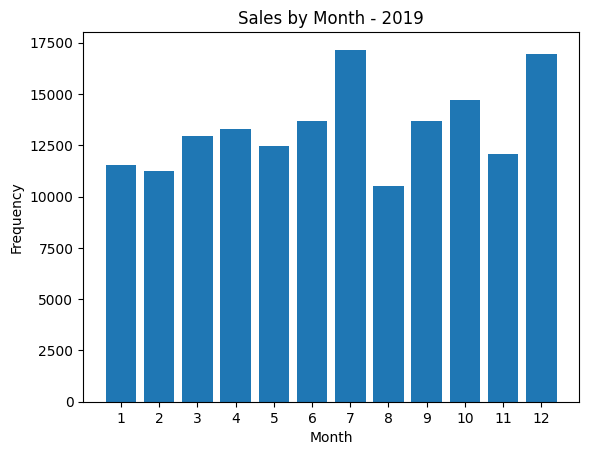

In [24]:
plt.bar(range(1 , 13), nb_vente_by_month)
plt.xticks(range(1 , 13))
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Sales by Month - 2019')

<BarContainer object of 4 artists>

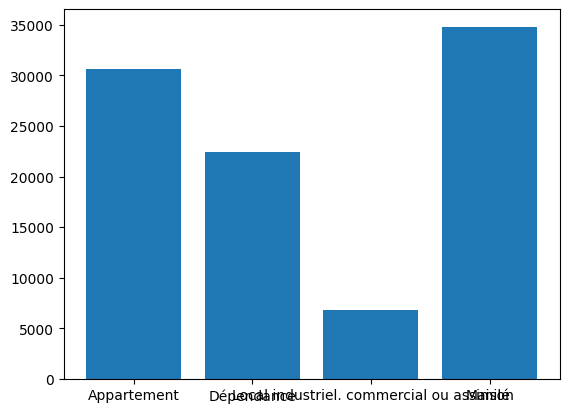

In [25]:
df_count_by_local = pd.DataFrame(df2019_sample_small.groupby(by = 'type_local').apply(count_rows).reset_index())

df_count_by_local = df_count_by_local.rename(columns={0: "count"})

plt.bar(df_count_by_local['type_local'] , df_count_by_local['count'])



<BarContainer object of 26 artists>

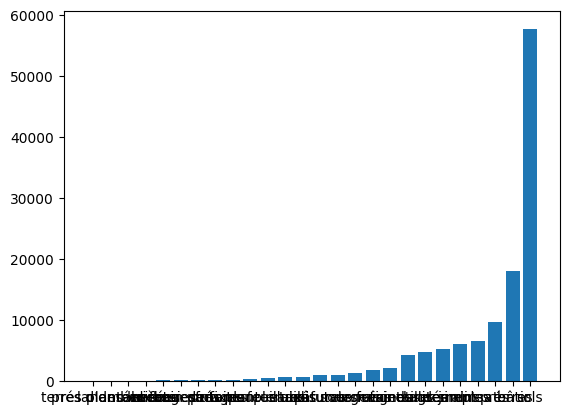

In [26]:
df_count_by_culture = pd.DataFrame(df2019_sample_small.groupby(by = 'nature_culture').apply(count_rows).reset_index())

df_count_by_culture = df_count_by_culture.rename(columns = {0 : 'frequency'})

df_count_by_culture = df_count_by_culture.sort_values(by = 'frequency')

plt.bar(df_count_by_culture['nature_culture'] , df_count_by_culture['frequency'])

In [27]:
mask_prix_m_carre_diff_inf = df2019_sample_small['prix_m_carre'] != np.inf

df_price_by_region = pd.DataFrame(df2019_sample_small[mask_prix_m_carre_diff_inf].groupby(by = 'nom_region')['prix_m_carre'].mean().reset_index())

px.bar(df_price_by_region , x = 'nom_region' , y = 'prix_m_carre')

In [28]:
df_price_by_dept = pd.DataFrame(df2019_sample_small[mask_prix_m_carre_diff_inf].groupby(by = 'nom_departement')['prix_m_carre'].mean().reset_index())

px.bar(df_price_by_dept , x = 'nom_departement' , y = 'prix_m_carre')

In [29]:
df_price_by_month = pd.DataFrame(df2019_sample_small[mask_prix_m_carre_diff_inf].groupby(by = 'mutation_month')['prix_m_carre'].mean().reset_index())

px.bar(df_price_by_month , x = 'mutation_month' , y = 'prix_m_carre')

Text(0.5, 1.0, 'Sales by Month - 2019')

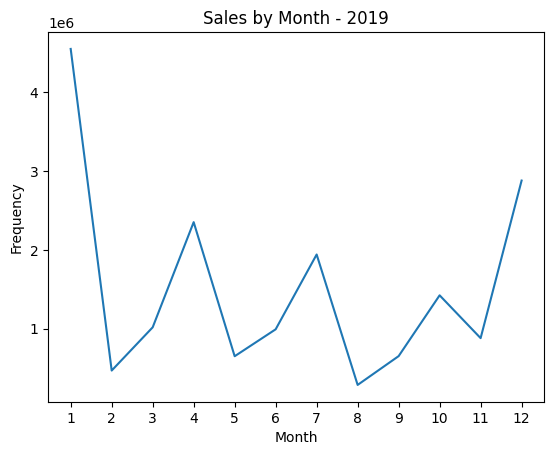

In [30]:
price_mean_by_month = df2019_sample_small[mask_vente].groupby(by = 'mutation_month')['valeur_fonciere'].mean()

plt.plot(range(1 , 13), price_mean_by_month)
plt.xticks(range(1 , 13))
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Sales by Month - 2019')

## Departements

In [31]:
departements_str = df2019_sample_small['code_departement'].apply(lambda x : str(x)).unique()

departements = df2019_sample_small['code_departement'].unique()

departements

array(['85', '51', '78', '89', '14', '17', '31', '06', '22', '13', '47',
       '18', '73', '44', '80', '42', '37', '91', '84', '08', '45', '974',
       '75', '77', '16', '59', '81', '61', '15', '11', '52', '53', '76',
       '65', '83', '02', '32', '95', '92', '33', '69', '25', '71', '56',
       '87', '49', '74', '07', '46', '19', '28', '40', '72', '63', '03',
       '24', '34', '88', '70', '36', '55', '2B', '01', '21', '26', '94',
       '30', '971', '60', '12', '50', '54', '27', '41', '62', '29', '05',
       '04', '82', '86', '39', '35', '38', '43', '93', '10', '90', '79',
       '23', '58', '66', '48', '973', '2A', '64', '09', '972'],
      dtype=object)

In [32]:
departements.size

97

<BarContainer object of 97 artists>

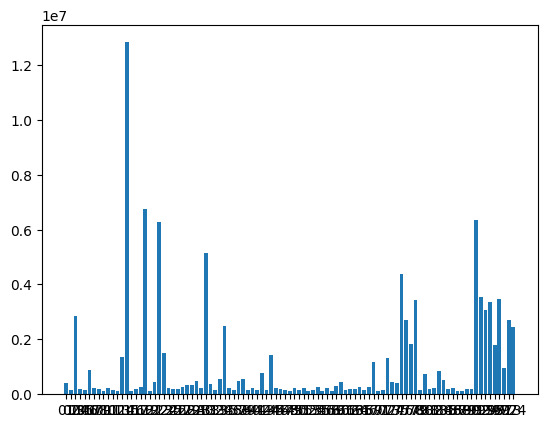

In [33]:
df_sale_price_by_dept = df2019_sample_small[mask_vente].groupby(by = 'code_departement')['valeur_fonciere'].mean().reset_index()

plt.bar(df_sale_price_by_dept['code_departement'] , df_sale_price_by_dept['valeur_fonciere'])

In [34]:
locs = pd.DataFrame(df2019_sample_small[['latitude' , 'longitude']])

locs

,latitude,longitude
0,46.847310,-1.875529
1,49.260855,3.985962
2,49.062339,1.694961
3,47.630249,3.674335
4,48.935167,-0.723151
...,...,...
176656,49.270641,1.218010
176657,43.128258,2.561314
176658,47.349825,6.361707
176659,48.629211,2.421364


In [35]:
df2019_sample_small['nombre_pieces_principales'].sort_values().unique()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 18., 20., 30., 31., 33., 56., nan])

In [36]:
df2019_sample_small['type_local'].isna().sum()

81944

In [37]:
mask_local_nan = df2019_sample_small['type_local'].notna()

df2019_sample_small[mask_local_nan]

,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,mutation_month,nom_departement,code_region,nom_region,prix_m_carre
0,2019-1273553,2019-10-21,1,Vente,88000.0,42.0,NaN,RUE BONNE FONTAINE,4620,85300.0,...,NaN,NaN,NaN,-1.875529,46.847310,10,Vendée,52,Pays de la Loire,inf
1,2019-753371,2019-02-06,1,Vente,249000.0,9001.0,NaN,RUE DANTON,0160,51370.0,...,NaN,NaN,NaN,3.985962,49.260855,2,Marne,44,Grand Est,inf
2,2019-1162845,2019-06-20,1,Vente,115765.0,2.0,NaN,PAS DU PORT,0810,78840.0,...,NaN,NaN,62.0,1.694961,49.062339,6,Yvelines,11,Île-de-France,2.463085e+03
4,2019-189484,2019-01-19,1,Vente,142000.0,5204.0,NaN,CHENE LAMOTTE- MONTCHAUVET,E375,14350.0,...,NaN,NaN,500.0,-0.723151,48.935167,1,Calvados,28,Normandie,1.378641e+03
5,2019-752115,2019-09-04,1,Vente,90000.0,3.0,NaN,RUE DE LA MONTAGNE,0530,51190.0,...,NaN,NaN,187.0,4.004689,48.970890,9,Marne,44,Grand Est,7.086614e+02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176654,2019-850474,2019-06-18,1,Vente,240000.0,146.0,NaN,RUE DES TILLEULS CD310,0048,59470.0,...,NaN,NaN,279.0,2.343598,50.897076,6,Nord,32,Hauts-de-France,1.702128e+03
176655,2019-1185465,2019-12-26,1,Vente,20035276.0,7.0,NaN,RUE DES RIEZ,6868,80000.0,...,NaN,NaN,NaN,2.333183,49.865475,12,Somme,32,Hauts-de-France,2.903663e+05
176656,2019-323386,2019-11-28,1,Vente,277000.0,1.0,NaN,VOIE FANTASTIQUE,0106,27100.0,...,NaN,NaN,25392.0,1.218010,49.270641,11,Eure,28,Normandie,3.597403e+03
176658,2019-295608,2019-10-18,1,Vente,105000.0,2.0,NaN,RUE DES FRERES GRENIER,0840,25110.0,...,NaN,NaN,NaN,6.361707,47.349825,10,Doubs,27,Bourgogne-Franche-Comté,1.265060e+03


In [38]:
mask_nb_piece_0 = df2019_sample_small['nombre_pieces_principales'] == 1

df2019_sample_small[mask_local_nan][mask_nb_piece_0]



/Library/Python/3.7/site-packages/ipykernel_launcher.py:3: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,...,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude,mutation_month,nom_departement,code_region,nom_region,prix_m_carre
19,2019-1318352,2019-04-10,1,Vente,115000.0,39.0,NaN,RUE PIERRE SEMARD,2860,91270.0,...,NaN,NaN,NaN,2.435546,48.697055,4,Essonne,11,Île-de-France,3285.714286
26,2019-1474159,2019-08-27,1,Vente,185000.0,78.0,NaN,RUE NOTRE DAME DES CHAMPS,6838,75006.0,...,NaN,NaN,NaN,2.331734,48.842244,8,Paris,11,Île-de-France,23125.000000
35,2019-1134008,2019-07-08,1,Vente,9311309.0,4.0,NaN,ALL BUISSONNIERE,1323,77186.0,...,NaN,NaN,4464.0,2.622004,48.843324,7,Seine-et-Marne,11,Île-de-France,517294.944444
43,2019-961816,2019-11-29,1,Vente,55810.0,6.0,NaN,RUE RICHELIEU,0175,65110.0,...,NaN,NaN,NaN,-0.113005,42.888846,11,Hautes-Pyrénées,76,Occitanie,1924.482759
75,2019-167903,2019-03-22,1,Vente,840000.0,9056.0,NaN,AV DE LA LIBERATION,2748,13200.0,...,NaN,NaN,1454.0,4.650513,43.721694,3,Bouches-du-Rhône,93,Provence-Alpes-Côte d'Azur,70000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176461,2019-42317,2019-09-26,1,Vente en l'état futur d'achèvement,100800.0,5000.0,NaN,AV DES MARTYRS,0345,5230.0,...,NaN,NaN,NaN,6.273278,44.546845,9,Hautes-Alpes,93,Provence-Alpes-Côte d'Azur,3733.333333
176485,2019-899564,2019-03-28,1,Vente,91000.0,142.0,NaN,RUE DE LA REPUBLIQUE,2300,62700.0,...,NaN,NaN,640.0,2.542872,50.480317,3,Pas-de-Calais,32,Hauts-de-France,7583.333333
176609,2019-617346,2019-03-14,1,Vente,107500.0,5.0,NaN,IMP GARIBALDI,3860,42000.0,...,NaN,NaN,217.0,4.404262,45.450874,3,Loire,84,Auvergne-Rhône-Alpes,1853.448276
176624,2019-1477750,2019-07-24,1,Vente,320300.0,142.0,NaN,RUE DU FBG ST MARTIN,3522,75010.0,...,NaN,NaN,NaN,2.359714,48.874871,7,Paris,11,Île-de-France,11044.827586
